# Drought Duration: Past, Present, and Future

In this tutorial, we explore how drought duration has changed over time and how it might change in the future for Central Greece (NUTS2 region EL64). To keep it simple, we'll use data that has been preprocessed using the [how-to guide on drought duration using ECDE data](../how-to-guides/drought_duration_ecde.ipynb).

```{admonition} Learning Objectives
:class: tip
By the end of this tutorial, you will understand:
- How to analyze observed changes in drought duration using reanalysis data
- How climate models simulate historical droughts
- How to interpret future drought projections
- Why multiple climate models are essential for assessing uncertainty
- The importance of comparing projections to historical baselines
```

```{admonition} Prerequisites
:class: note
For Central Greece, we have preprocessed the data for the data for you. If you change the administrative region, you'll need to run the [how-to guide on drought duration using ECDE data](../how-to-guides/drought_duration_ecde.ipynb) to download and process the data for your region. 
```

## Setup

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

# Configure plotting
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [19]:
# Configuration
admin_id = 'EL64'
# Paths
workdir = Path("/home/nejk/code/drought_exposure")
os.chdir(workdir)
data_dir = workdir / 'data' / admin_id / 'drought_hazard'

# Load preprocessed data
hist_file = data_dir / f'drought_duration_historical_{admin_id}.csv'
proj_file = data_dir / f'drought_duration_projections_{admin_id}.csv'

print(f"Region: {admin_id} (Central Greece)")
print(f"Historical data: {hist_file}")
print(f"Projection data: {proj_file}")

Region: EL64 (Central Greece)
Historical data: /home/nejk/code/drought_exposure/data/EL64/drought_hazard/drought_duration_historical_EL64.csv
Projection data: /home/nejk/code/drought_exposure/data/EL64/drought_hazard/drought_duration_projections_EL64.csv


## Step 1: Observed Historical Change in Drought Duration

We begin by examining the **observed record** of drought duration using reanalysis data. Reanalysis combines historical observations with weather models to create a consistent, gridded dataset of past climate.

Let's load the historical data and visualize the trend:

In [20]:
# Load historical reanalysis data
hist_df = pd.read_csv(hist_file)
hist_df['time'] = pd.to_datetime(hist_df['time'])
hist_df = hist_df.sort_values('time')

print(f"Historical data: {hist_df['time'].min().year} to {hist_df['time'].max().year}")
print(f"Number of years: {len(hist_df)}")
hist_df.head()

Historical data: 1940 to 2023
Number of years: 336


,time,realization,nuts,dmd,scenario,model
0,1940-01-01,0,EL64,0.151107,historical,reanalysis
168,1940-01-01,0,EL64,0.151107,historical,reanalysis
84,1940-01-01,0,EL64,0.151107,historical,reanalysis
252,1940-01-01,0,EL64,0.151107,historical,reanalysis
1,1941-01-01,0,EL64,1.546539,historical,reanalysis


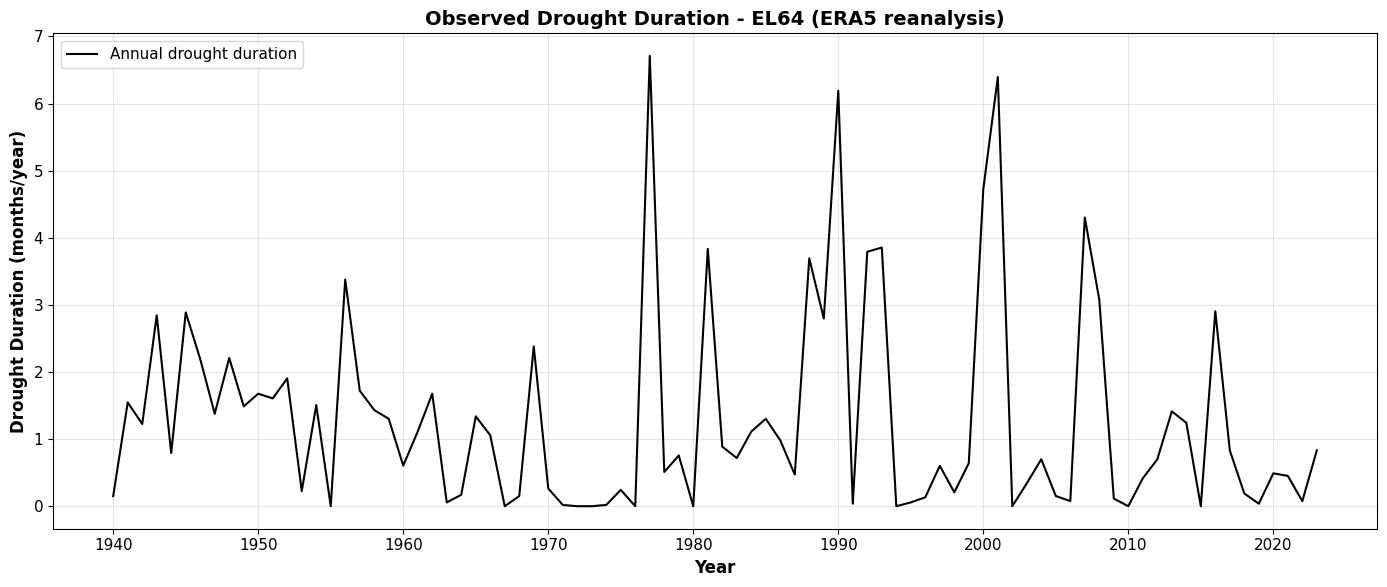


Observed drought duration statistics:
  Mean: 1.30 months/year
  Std: 1.53 months/year
  Min: 0.00 months/year (1955)
  Max: 6.71 months/year (1977)


In [21]:
# Plot observed drought duration
fig, ax = plt.subplots(figsize=(14, 6))

# Plot annual values
ax.plot(hist_df['time'], hist_df['dmd'], 
        color='black', linewidth=1.5, label='Annual drought duration')


ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought duration (months/year)', fontsize=12)
ax.set_title(f'Observed Drought Duration - {admin_id} (ERA5 reanalysis)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Calculate basic statistics
print(f"\nObserved drought duration statistics:")
print(f"  Mean: {hist_df['dmd'].mean():.2f} months/year")
print(f"  Std: {hist_df['dmd'].std():.2f} months/year")

print(f"  Min: {hist_df['dmd'].min():.2f} months/year ({hist_df.loc[hist_df['dmd'].idxmin(), 'time'].year})")print(f"  Max: {hist_df['dmd'].max():.2f} months/year ({hist_df.loc[hist_df['dmd'].idxmax(), 'time'].year})")

## Step 2: Simulated Historical Change (Climate Models)

Now let's see how **climate models** simulate the same historical period. Climate models are our tools for understanding future climate, but first we need to check if they can reproduce the past.

We'll start by examining **one climate model** to understand the basics:

In [22]:
# Load projection data (includes historical model runs)
proj_df = pd.read_csv(proj_file)
proj_df['time'] = pd.to_datetime(proj_df['time'])
proj_df = proj_df.sort_values('time')

print(f"Projection data: {proj_df['time'].min().year} to {proj_df['time'].max().year}")
print(f"\nAvailable climate models: {proj_df['model'].nunique()}")
print(f"Available scenarios: {sorted(proj_df['scenario'].unique())}")

# Select one model for demonstration
example_model = 'ec_earth_hirham5_rcp4_5_r3i1p1'
print(f"\nExample model for demonstration: {example_model}")

Projection data: 1950 to 2100

Available climate models: 18
Available scenarios: ['RCP4_5', 'RCP8_5']

Example model for demonstration: ec_earth_hirham5_rcp4_5_r3i1p1


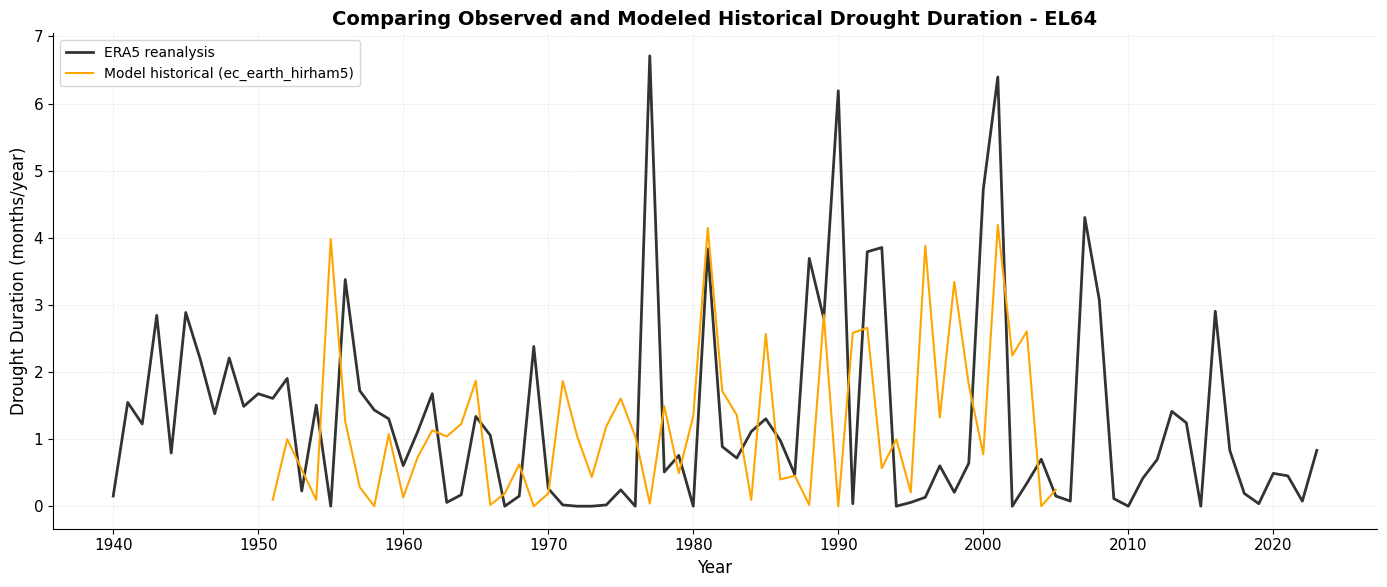


💡 Key Insight: Climate models simulate the historical period (1951-2005) to validate
   their ability to reproduce past climate before making future projections.


In [ ]:
# Extract one model's data
model_df = proj_df[proj_df['model'] == example_model].copy()

# Split into historical and projection periods
hist_period = model_df[model_df['time'].dt.year <= 2005]
proj_period = model_df[model_df['time'].dt.year > 2005]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

# Reanalysis (observations)
ax.plot(hist_df['time'], hist_df['dmd'], 
        color='black', linewidth=2, label='ERA5 reanalysis', alpha=0.8)

# Model historical period
ax.plot(hist_period['time'], hist_period['dmd'], 
        color='orange', linewidth=1.5, label=f'Model historical ({example_model.split("_rcp")[0]})', 
        linestyle='-', alpha=1)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought duration (months/year)', fontsize=12)
ax.set_title(f'Comparing Observed and Modeled Historical Drought Duration - {admin_id}', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insight: Climate models simulate the historical period (1951-2005) to validate")
print(f"   their ability to reproduce past climate before making future projections.")

## Step 3: Projected Change in Drought Duration

Now we can look at future projections. Let's first see what **one model** projects for the future under a moderate emissions scenario (RCP4.5):

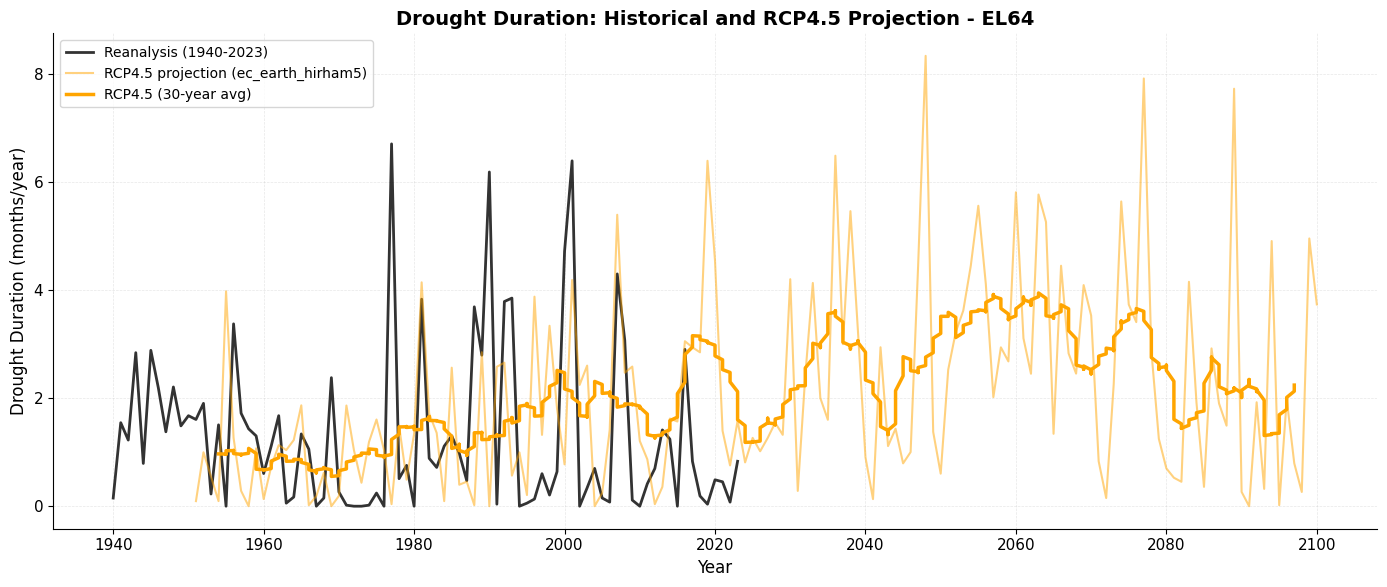


Projected change (2071-2100 vs 1971-2000):
  Baseline (1971-2000): 1.41 days/year
  Future (2071-2100): 2.31 days/year
  Change: +0.91 days/year (+64.3%)


In [ ]:
# Plot complete timeseries with projection
fig, ax = plt.subplots(figsize=(14, 6))

# Reanalysis
ax.plot(hist_df['time'], hist_df['dmd'], 
        color='black', linewidth=2, label='ERA5 reanalysis', alpha=0.8)

# Model projection (RCP4.5)
ax.plot(model_df['time'], model_df['dmd'], 
        color='orange', linewidth=1.5, label=f'RCP4.5 projection ({example_model.split("_rcp")[0]})', 
        alpha=0.5)

# Add 30-year rolling mean for projection
proj_rolling = model_df.set_index('time')['dmd'].rolling(window=30, center=True).mean()
ax.plot(proj_rolling.index, proj_rolling.values, 
        color='orange', linewidth=2.5, label='RCP4.5 (30-year avg)', alpha=1)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought duration (months/year)', fontsize=12)
ax.set_title(f'Drought Duration: Historical and RCP4.5 Projection - {admin_id}', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Calculate change
baseline = model_df[model_df['time'].dt.year.between(1971, 2000)]['dmd'].mean()
future = model_df[model_df['time'].dt.year.between(2071, 2100)]['dmd'].mean()
change = future - baseline

print(f"\nProjected change (2071-2100 vs 1971-2000):")
print(f"  Baseline (1971-2000): {baseline:.2f} days/year")
print(f"  Future (2071-2100): {future:.2f} days/year")
print(f"  Change: {change:+.2f} days/year ({(change/baseline)*100:+.1f}%)")

## Best Practice 1: Using Multiple Climate Models

```{admonition} Why Multiple Models?
:class: important
A single climate model gives us **one possible future**, but climate models have uncertainties. Using multiple models helps us understand the **range of possible futures** and assess the confidence in our projections.
```

Let's compare multiple climate models:

In [25]:
# Select RCP4.5 models
rcp45_df = proj_df[proj_df['scenario'] == 'RCP4_5'].copy()

# Get unique models
models = rcp45_df['model'].unique()
print(f"Number of RCP4.5 model combinations: {len(models)}")
print(f"\nModels included:")
for model in sorted(models):
    print(f"  - {model}")

Number of RCP4.5 model combinations: 9

Models included:
  - ec_earth_hirham5_rcp4_5_r3i1p1
  - ec_earth_racmo22e_rcp4_5_r1i1p1
  - ec_earth_rca4_rcp4_5_r12i1p1
  - hadgem2_es_racmo22e_rcp4_5_r1i1p1
  - hadgem2_es_rca4_rcp4_5_r1i1p1
  - ipsl_cm5a_mr_wrf381p_rcp4_5_r1i1p1
  - mpi_esm_lr_cclm4_8_17_rcp4_5_r1i1p1
  - mpi_esm_lr_rca4_rcp4_5_r1i1p1
  - noresm1_m_hirham5_rcp4_5_r1i1p1


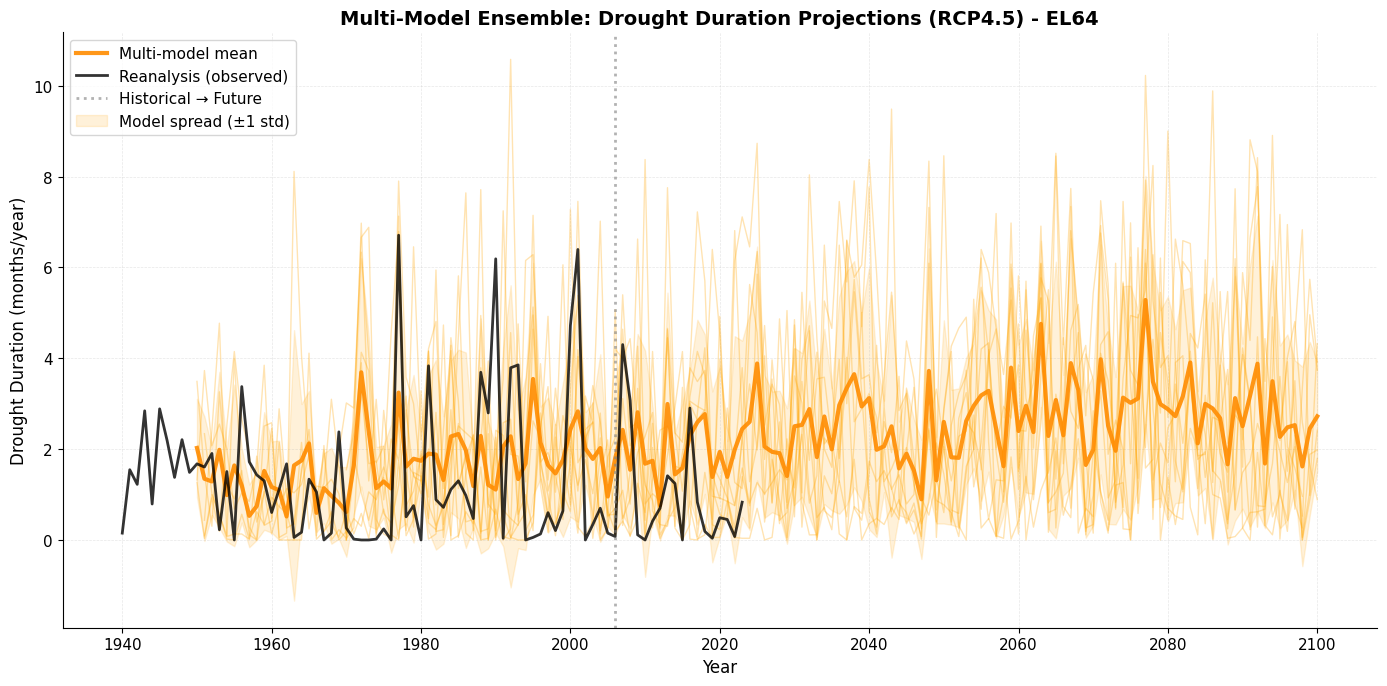


💡 Key Insight: The spread among models shows the uncertainty in projections.
   The multi-model mean provides a more robust estimate than any single model.


In [ ]:
# Plot all RCP4.5 models
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each model
for model in models:
    model_data = rcp45_df[rcp45_df['model'] == model]
    ax.plot(model_data['time'], model_data['dmd'], 
            linewidth=1, alpha=0.3, color='orange')

# Calculate and plot ensemble mean
ensemble_mean = rcp45_df.groupby('time')['dmd'].mean().reset_index()
ax.plot(ensemble_mean['time'], ensemble_mean['dmd'], 
        color='darkorange', linewidth=3, label='Multi-model mean', alpha=0.9)

# Add reanalysis for reference
ax.plot(hist_df['time'], hist_df['dmd'], 
        color='black', linewidth=2, label='ERA5 reanalysis', alpha=0.8)

# Mark transition
ax.axvline(pd.Timestamp('2005-12-31'), color='gray', linestyle=':', 
           linewidth=2, label='Historical → Future', alpha=0.6)

# Add shading for model spread
ensemble_std = rcp45_df.groupby('time')['dmd'].std().reset_index()
ensemble_data = ensemble_mean.merge(ensemble_std, on='time', suffixes=('_mean', '_std'))
ax.fill_between(ensemble_data['time'], 
                ensemble_data['dmd_mean'] - ensemble_data['dmd_std'],
                ensemble_data['dmd_mean'] + ensemble_data['dmd_std'],
                alpha=0.15, color='orange', label='Model spread (±1 std)')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought duration (months/year)', fontsize=12)
ax.set_title(f'Multi-Model Ensemble: Drought Duration Projections (RCP4.5) - {admin_id}', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(bottom=0)  # Drought duration cannot be negative

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insight: The spread among models shows the uncertainty in projections.")
print(f"   The multi-model mean provides a more robust estimate than any single model.")

## Best Practice 2: Comparing to Historical Baselines

```{admonition} Why Compare to Baselines?
:class: important
Climate change impacts are measured as **changes from a baseline period**. The World Meteorological Organization recommends using a 30-year baseline (typically 1971-2000 or 1981-2010) to account for natural climate variability.
```

Let's calculate projected changes relative to the historical baseline:

In [42]:
# Define baseline and future periods
baseline_years = (1971, 2000)
future_periods = {
    'Near-term (2021-2050)': (2021, 2050),
    'Mid-term (2041-2070)': (2041, 2070),
    'Long-term (2071-2100)': (2071, 2100)
}

# Calculate baseline from reanalysis
baseline_obs = hist_df[
    hist_df['time'].dt.year.between(*baseline_years)
]['dmd'].mean()

print(f"Historical baseline ({baseline_years[0]}-{baseline_years[1]}):")
print(f"  Observed (reanalysis): {baseline_obs:.2f} months/year")

# Calculate baseline from models
baseline_model = rcp45_df[
    rcp45_df['time'].dt.year.between(*baseline_years)
].groupby('model')['dmd'].mean()

print(f"  Multi-model mean: {baseline_model.mean():.2f} ± {baseline_model.std():.2f} months/year")

# Calculate changes for each future period
print(f"\nProjected changes (RCP4.5) from baseline:")
for period_name, (start, end) in future_periods.items():
    future_vals = rcp45_df[
        rcp45_df['time'].dt.year.between(start, end)
    ].groupby('model')['dmd'].mean()
    
    changes = future_vals - baseline_model
    
    print(f"\n  {period_name}:")
    print(f"    Mean change: {changes.mean():+.2f} months/year ({(changes.mean()/baseline_obs)*100:+.1f}%)")
    print(f"    Range: {changes.min():+.2f} to {changes.max():+.2f} months/year")
    print(f"    Agreement: {(changes > 0).sum()}/{len(changes)} models show increase")

Historical baseline (1971-2000):
  Observed (reanalysis): 1.48 months/year
  Multi-model mean: 1.92 ± 0.34 months/year

Projected changes (RCP4.5) from baseline:

  Near-term (2021-2050):
    Mean change: +0.42 months/year (+28.6%)
    Range: -0.86 to +1.71 months/year
    Agreement: 6/9 models show increase

  Mid-term (2041-2070):
    Mean change: +0.57 months/year (+38.6%)
    Range: -0.26 to +1.74 months/year
    Agreement: 8/9 models show increase

  Long-term (2071-2100):
    Mean change: +0.97 months/year (+65.6%)
    Range: +0.07 to +2.02 months/year
    Agreement: 9/9 models show increase


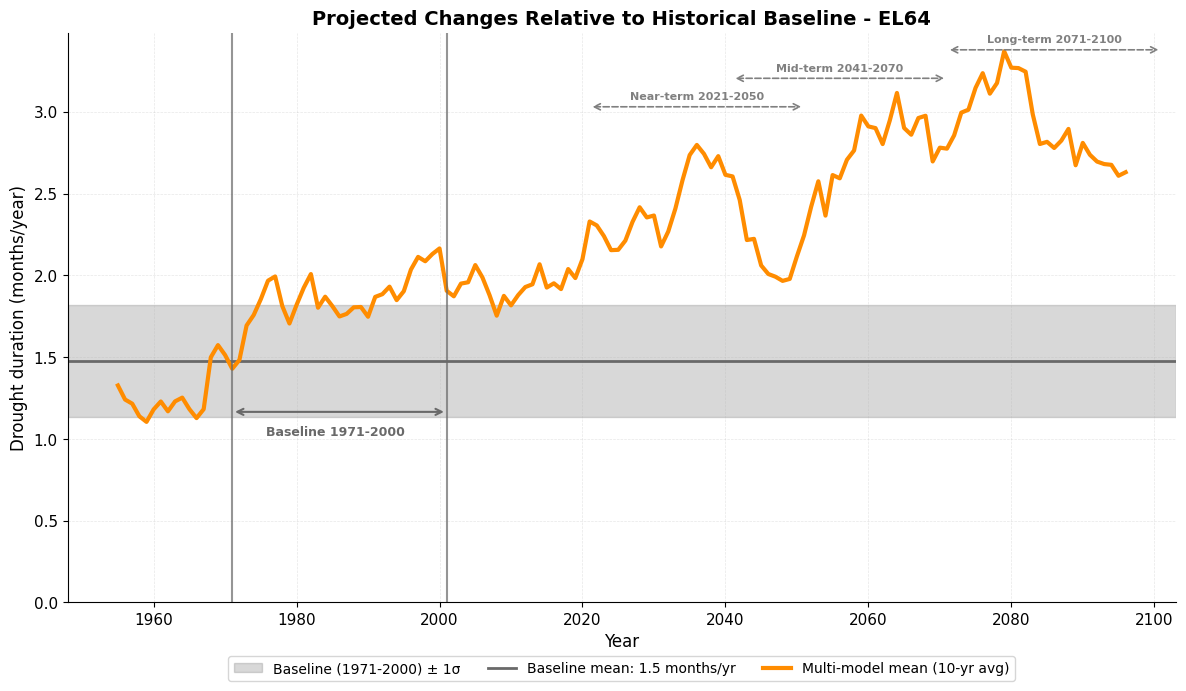

In [52]:
# Create a visual comparison
fig, ax = plt.subplots(figsize=(12, 7))

# Calculate 30-year running means for each model
period_means = []
for model in models:
    model_data = rcp45_df[rcp45_df['model'] == model].set_index('time')['dmd']
    rolling_30yr = model_data.rolling(window=30*12, center=True).mean()  # Assuming monthly data
    period_means.append(rolling_30yr)

# Plot baseline period
ax.axhspan(baseline_obs - baseline_model.std(), 
           baseline_obs + baseline_model.std(),
           alpha=0.3, color='gray', label=f'Baseline ({baseline_years[0]}-{baseline_years[1]}) ± 1σ')
ax.axhline(baseline_obs, color='dimgray', linestyle='-', linewidth=2, 
          label=f'Baseline mean: {baseline_obs:.1f} months/yr')

# Plot multi-model ensemble mean with rolling average
ensemble_rolling = ensemble_mean.set_index('time')['dmd'].rolling(window=10, center=True).mean()
ax.plot(ensemble_rolling.index, ensemble_rolling.values, 
        color='darkorange', linewidth=3, label='Multi-model mean (10-yr avg)')

# Mark baseline period with vertical bars
ax.axvline(pd.Timestamp('1971-01-01'), color='dimgray', linestyle='-', linewidth=1.5, alpha=0.7)
ax.axvline(pd.Timestamp('2000-12-31'), color='dimgray', linestyle='-', linewidth=1.5, alpha=0.7)

# Add horizontal arrow showing baseline extent at bottom
y_min = ax.get_ylim()[0]
y_bottom = y_min + (ax.get_ylim()[1] - y_min) * 0.07
ax.annotate('', xy=(pd.Timestamp('2000-12-31'), y_bottom), 
            xytext=(pd.Timestamp('1971-01-01'), y_bottom),
            arrowprops=dict(arrowstyle='<->', color='dimgray', lw=1.5))
ax.text(pd.Timestamp('1985-06-30'), y_bottom * 0.93, 'Baseline 1971-2000', 
        ha='center', va='top', fontsize=9, color='dimgray', fontweight='bold')

# Mark future periods with horizontal arrows at different heights (reversed order: long-term highest)
period_info = [
    ('2071-01-01', '2100-12-31', 'Long-term 2071-2100', 0.97),
    ('2041-01-01', '2070-12-31', 'Mid-term 2041-2070', 0.92),
    ('2021-01-01', '2050-12-31', 'Near-term 2021-2050', 0.87)
]

y_max = ax.get_ylim()[1]
for start_date, end_date, label, height_factor in period_info:
    y_pos = y_max * height_factor
    ax.annotate('', xy=(pd.Timestamp(end_date), y_pos), 
                xytext=(pd.Timestamp(start_date), y_pos),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2, linestyle='--'))
    # Calculate midpoint for text
    mid_date = pd.Timestamp(start_date) + (pd.Timestamp(end_date) - pd.Timestamp(start_date)) / 2
    ax.text(mid_date, y_pos * 1.01, label, 
            ha='center', va='bottom', fontsize=8, color='gray', fontweight='bold')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought duration (months/year)', fontsize=12)
ax.set_title(f'Projected Changes Relative to Historical Baseline - {admin_id}', 
             fontsize=14, fontweight='bold')
ax.set_ylim(bottom=0)  # Drought duration cannot be negative
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## Comparing Emission Scenarios

Finally, let's compare different emission scenarios (RCP4.5 vs RCP8.5) to understand how different levels of greenhouse gas emissions could affect future drought duration:

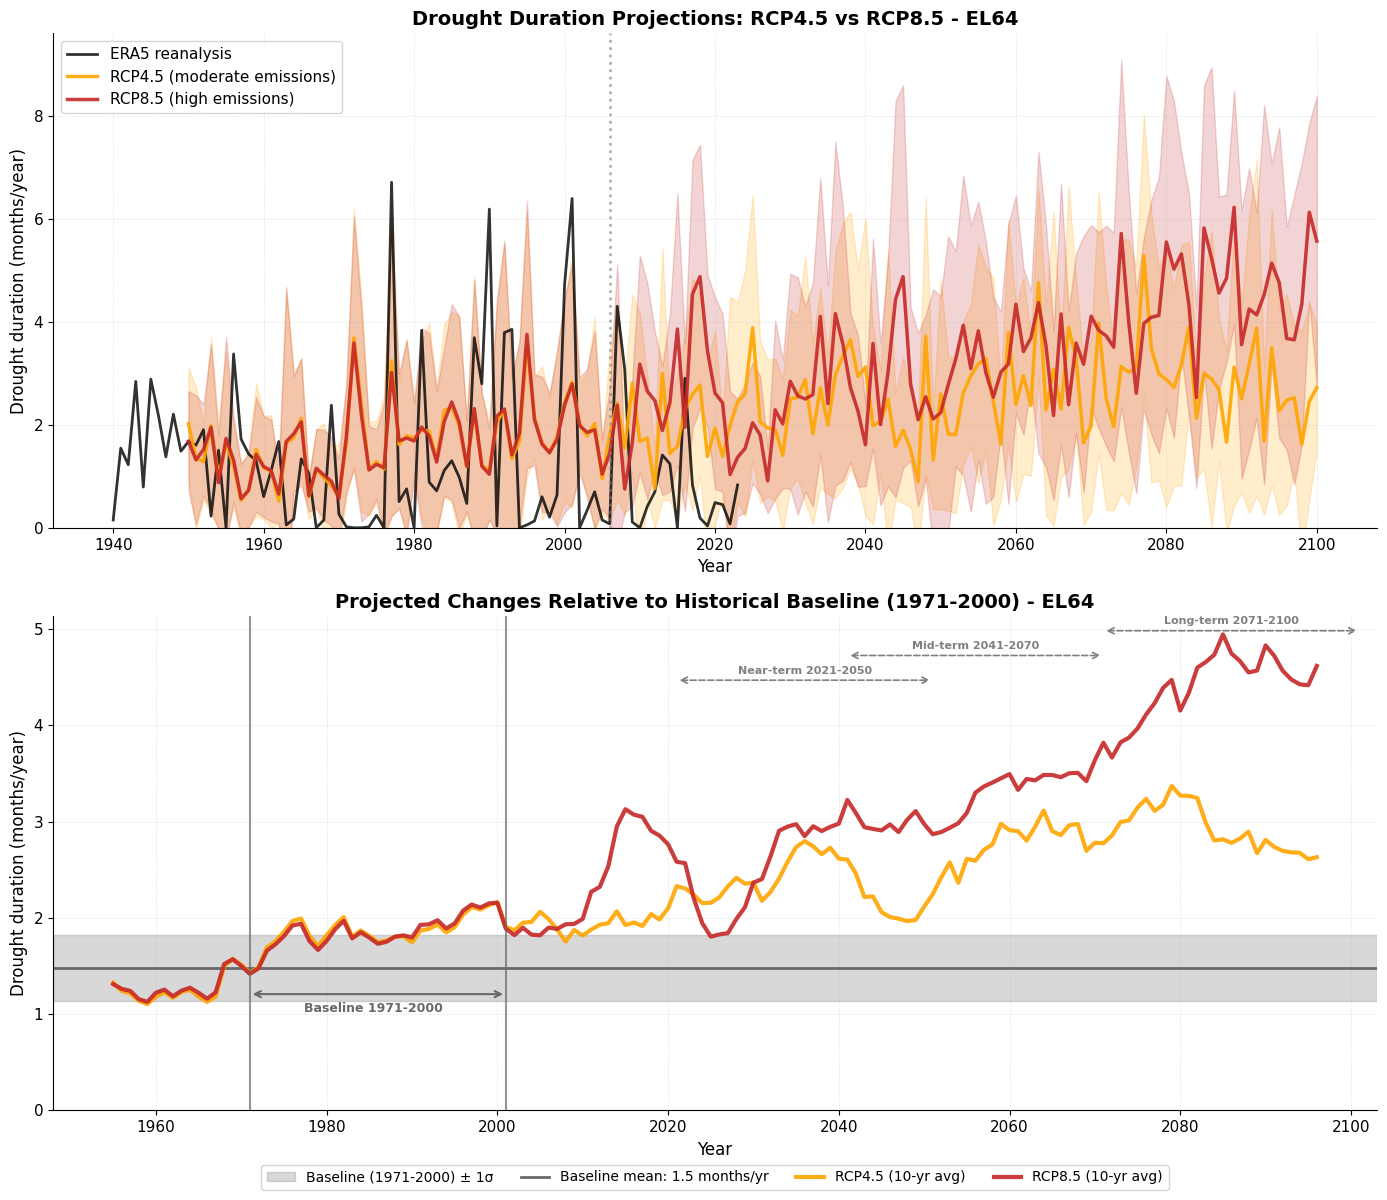


End of century (2071-2100) comparison:
  Mitigation efforts can reduce future drought risk.
  RCP8.5: 4.47 ± 1.16 months/year
  Difference: 1.58 months/year
  RCP4.5: 2.89 ± 0.61 months/year

💡 Key Insight: Higher emissions (RCP8.5) lead to longer lasting droughts.


In [54]:
# Prepare data for both scenarios
rcp85_df = proj_df[proj_df['scenario'] == 'RCP8_5'].copy()

# Calculate ensemble means for both scenarios
rcp45_mean = rcp45_df.groupby('time')['dmd'].mean().reset_index()
rcp85_mean = rcp85_df.groupby('time')['dmd'].mean().reset_index()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# ========== Top plot: Scenario comparison ==========
# Reanalysis
ax1.plot(hist_df['time'], hist_df['dmd'], 
        color='black', linewidth=2, label='ERA5 reanalysis', alpha=0.8)

# RCP4.5
ax1.plot(rcp45_mean['time'], rcp45_mean['dmd'], 
        color='orange', linewidth=2.5, label='RCP4.5 (moderate emissions)', alpha=0.9)

# RCP8.5
ax1.plot(rcp85_mean['time'], rcp85_mean['dmd'], 
        color='#c62828', linewidth=2.5, label='RCP8.5 (high emissions)', alpha=0.9)

# Add spread for both scenarios
rcp45_std = rcp45_df.groupby('time')['dmd'].std().reset_index()
rcp85_std = rcp85_df.groupby('time')['dmd'].std().reset_index()

ax1.fill_between(rcp45_mean['time'], 
                rcp45_mean['dmd'] - rcp45_std['dmd'],
                rcp45_mean['dmd'] + rcp45_std['dmd'],
                alpha=0.2, color='orange')

ax1.fill_between(rcp85_mean['time'], 
                rcp85_mean['dmd'] - rcp85_std['dmd'],
                rcp85_mean['dmd'] + rcp85_std['dmd'],
                alpha=0.2, color='#c62828')

# Mark transition
ax1.axvline(pd.Timestamp('2005-12-31'), color='gray', linestyle=':', 
           linewidth=2, alpha=0.6)

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylim(bottom=0)  # Drought duration cannot be negative
ax1.set_ylabel('Drought duration (months/year)', fontsize=12)
ax1.set_title(f'Drought Duration Projections: RCP4.5 vs RCP8.5 - {admin_id}', 
             fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=11, frameon=True)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ========== Bottom plot: Changes relative to baseline ==========
# Calculate baseline from both scenarios
baseline_rcp45 = rcp45_df[
    rcp45_df['time'].dt.year.between(1971, 2000)
].groupby('model')['dmd'].mean()

baseline_rcp85 = rcp85_df[
    rcp85_df['time'].dt.year.between(1971, 2000)
].groupby('model')['dmd'].mean()

# Plot baseline period
baseline_obs = hist_df[hist_df['time'].dt.year.between(1971, 2000)]['dmd'].mean()
ax2.axhspan(baseline_obs - baseline_rcp45.std(), 
           baseline_obs + baseline_rcp45.std(),
           alpha=0.3, color='gray', label=f'Baseline (1971-2000) ± 1σ')
ax2.axhline(baseline_obs, color='dimgray', linestyle='-', linewidth=2, 
          label=f'Baseline mean: {baseline_obs:.1f} months/yr')

# Plot ensemble means with rolling average
rcp45_rolling = rcp45_mean.set_index('time')['dmd'].rolling(window=10, center=True).mean()
rcp85_rolling = rcp85_mean.set_index('time')['dmd'].rolling(window=10, center=True).mean()

ax2.plot(rcp45_rolling.index, rcp45_rolling.values, 
        color='orange', linewidth=3, label='RCP4.5 (10-yr avg)', alpha=0.9)
ax2.plot(rcp85_rolling.index, rcp85_rolling.values, 
        color='#c62828', linewidth=3, label='RCP8.5 (10-yr avg)', alpha=0.9)

# Mark baseline period with vertical bars
ax2.axvline(pd.Timestamp('1971-01-01'), color='dimgray', linestyle='-', linewidth=1.5, alpha=0.7)
ax2.axvline(pd.Timestamp('2000-12-31'), color='dimgray', linestyle='-', linewidth=1.5, alpha=0.7)

# Add horizontal arrow showing baseline extent at bottom
y_min = ax2.get_ylim()[0]
y_bottom = y_min + (ax2.get_ylim()[1] - y_min) * 0.07
ax2.annotate('', xy=(pd.Timestamp('2000-12-31'), y_bottom), 
            xytext=(pd.Timestamp('1971-01-01'), y_bottom),
            arrowprops=dict(arrowstyle='<->', color='dimgray', lw=1.5))
ax2.text(pd.Timestamp('1985-06-30'), y_bottom * 0.93, 'Baseline 1971-2000', 
        ha='center', va='top', fontsize=9, color='dimgray', fontweight='bold')

# Mark future periods with horizontal arrows at different heights (reversed order: long-term highest)
period_info = [
    ('2071-01-01', '2100-12-31', 'Long-term 2071-2100', 0.97),
    ('2041-01-01', '2070-12-31', 'Mid-term 2041-2070', 0.92),
    ('2021-01-01', '2050-12-31', 'Near-term 2021-2050', 0.87)
]

y_max = ax2.get_ylim()[1]
for start_date, end_date, label, height_factor in period_info:
    y_pos = y_max * height_factor
    ax2.annotate('', xy=(pd.Timestamp(end_date), y_pos), 
                xytext=(pd.Timestamp(start_date), y_pos),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2, linestyle='--'))
    # Calculate midpoint for text
    mid_date = pd.Timestamp(start_date) + (pd.Timestamp(end_date) - pd.Timestamp(start_date)) / 2
    ax2.text(mid_date, y_pos * 1.01, label, 
            ha='center', va='bottom', fontsize=8, color='gray', fontweight='bold')

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Drought duration (months/year)', fontsize=12)
ax2.set_title(f'Projected Changes Relative to Historical Baseline (1971-2000) - {admin_id}', 
             fontsize=14, fontweight='bold')
ax2.set_ylim(bottom=0)  # Drought duration cannot be negative
ax2.legend(loc='lower center', bbox_to_anchor=(0.5, -0.175), ncol=4, fontsize=10, frameon=True)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Calculate end-of-century differences
eoc_45 = rcp45_df[rcp45_df['time'].dt.year.between(2071, 2100)].groupby('model')['dmd'].mean()
eoc_85 = rcp85_df[rcp85_df['time'].dt.year.between(2071, 2100)].groupby('model')['dmd'].mean()



print(f"\nEnd of century (2071-2100) comparison:")
print(f"  Mitigation efforts can reduce future drought risk.")
print(f"  RCP8.5: {eoc_85.mean():.2f} ± {eoc_85.std():.2f} months/year")
print(f"  Difference: {(eoc_85.mean() - eoc_45.mean()):.2f} months/year")


print(f"  RCP4.5: {eoc_45.mean():.2f} ± {eoc_45.std():.2f} months/year")
print(f"\n💡 Key Insight: Higher emissions (RCP8.5) lead to longer lasting droughts.")

## Summary

In this tutorial, we've explored drought duration changes through three key steps:

### 📊 What we learned:

1. **Observed Changes**: Reanalysis data shows the historical drought record and natural variability
2. **Model Validation**: Climate models can simulate historical droughts, building confidence in their projections
3. **Future Projections**: Models project changes in drought duration under different emission scenarios

### 🎯 Best Practices:

```{admonition} Key Takeaways
:class: tip
✅ **Use multiple climate models** to assess uncertainty and get a robust estimate of future changes

✅ **Always compare projections to historical baselines** (typically 1971-2000 or 1981-2010) to quantify changes

✅ **Consider multiple emission scenarios** to understand the range of possible futures

✅ **Account for natural variability** using multi-year averages (e.g., 10-year or 30-year running means)
```

---

**Data Source**: European Climate Data Explorer (ECDE) - Climate Indicators via Copernicus Climate Data Store